<a href="https://colab.research.google.com/github/niuniu1fly-blip/spam-classification/blob/main/%E2%80%9Cspam_classification_project_ipynb%E2%80%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Team Members**


1.   Feiyang Lin  P942901
2.   Yiming Fang  P2942902



## **Project Intro**
This project presents the development of an AI-based system for SMS Spam Classification.
The aim of the project is to use text-based data, such as message content, length, and specific keywords, to predict whether a message is Spam (unwanted marketing/fraud) or Ham (legitimate communication).
The project is structured according to the main development stages required by the IMAT3707 module : data preparation, exploratory data analysis, model selection, and model evaluation

## **Import Libraries**
This section imports all the Python libraries required for data handling, visualisation, preprocessing, and machine learning.
Libraries such as Pandas and NumPy are used for data manipulation, while Matplotlib, Seaborn, and WordCloud are used for visual analysis.
Scikit-learn is imported to support text vectorization, dataset splitting, and the implementation of the Multinomial Naive Bayes model.



In [141]:
#import the basic library
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
import numpy as np
print("Import Libraries have achieved")

Import Libraries have achieved


## **Phase 1: Data Preparation**
In this section, we load the dataset, handle missing values, and perform text cleaning (Lemmatization and Stopword removal). This ensures the data is in a suitable format for the AI model

In [142]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [143]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [144]:
#deduplication
initial_count = len(df)
df = df.drop_duplicates(subset=['v2'])
print(f"Duplicates removed: {initial_count - len(df)}")

Duplicates removed: 403


In [145]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [146]:
# 2. 统一列名: Assume the first two columns are the relevant ones and rename them
df = df.iloc[:, :2] # Selects the first two columns
df.columns = ['label', 'text'] # Now rename them

df = df.dropna() # Drop rows with any NaN values after selecting columns
#统一标签
df['label'] = df['label'].str.lower()
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Redefine the clean_text function with the fix
def clean_text(text):
    # 处理可能的非字符串输入
    text = str(text).lower()
    text =  re.sub(r'([!?.$,])', r'\1' , text)
    words = text.split() # Corrected: used 'words' consistently
    # 词形还原并去除停用词
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

#应用清洗函数
df['clean_text'] = df['text'].apply(clean_text)
#提取长度特征
df['length'] = df['clean_text'].apply(len)


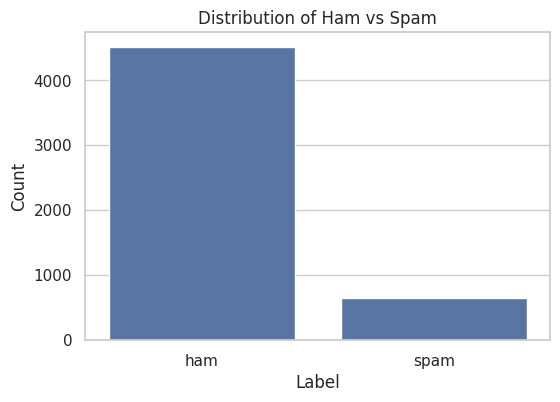

label
ham     0.87367
spam    0.12633
Name: proportion, dtype: float64


In [147]:
#设置绘图风格
sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Ham vs Spam')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()
#打印具体比例
print(df['label'].value_counts(normalize=True))

In [148]:
#特征工程：TF-IDF
#token_pattern允许长度为1的符号
tfidf = TfidfVectorizer(max_features=3000, token_pattern=r"(?u)\b\w+\b|[!?.$,%^&*()]")
X_tfidf = tfidf.fit_transform(df['clean_text'])
y = df['label_num']

In [149]:
#划分数据集
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

In [150]:
#smote
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [151]:
print(f"原始数据集大小：{len(df)}")
print(f"SMOTE处理后数据集大小:{X_train_res.shape[0]}")
print(f"测试集大小：{X_test.shape[0]}")


原始数据集大小：5169
SMOTE处理后数据集大小:7254
测试集大小：1034


## **Phase 2: Exploratory Data Analysis (EDA)**
We use visualizations to understand the characteristics of our data, such as the distribution of message lengths and common keywords in spam.

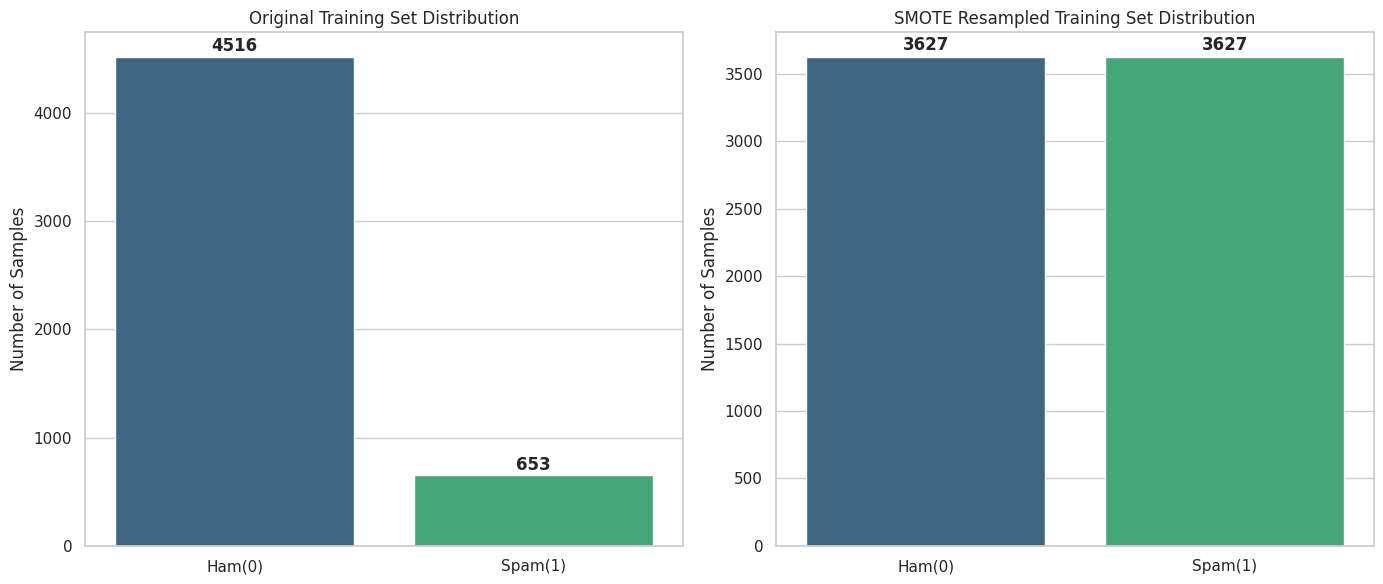

----Original Training Set Distribution----
original data - Ham:4516, Spam:653

----SMOTE Resampled Training Set Distribution----
SMOTE - Ham:3627, Spam:3627


In [152]:
#统计原始数据数量
original_counts = df['label'].value_counts()
# Removed y_train.value_counts().sort_index() as its output was not used.
#统计SMOTE处理后的数据数量
resampled_counts = pd.Series(y_train_res).value_counts().sort_index()
#绘图对比
fig,axes = plt.subplots(1,2,figsize=(14,6))
#图1：原始训练集分布
sns.barplot(x=['Ham(0)', 'Spam(1)'], y=original_counts.values, ax=axes[0], hue=['Ham(0)', 'Spam(1)'], palette='viridis', legend=False)
axes[0].set_title('Original Training Set Distribution')
axes[0].set_ylabel('Number of Samples') # Corrected 'ylable' to 'ylabel'
#在柱状图上标注数值
for i, v in enumerate(original_counts.values):
    axes[0].text(i, v + 50, str(v),ha='center', fontweight='bold')
#图2：SMOTE处理后分布
sns.barplot(x=['Ham(0)','Spam(1)'],y=resampled_counts.values,ax=axes[1],hue=['Ham(0)', 'Spam(1)'], palette='viridis', legend=False)
axes[1].set_title('SMOTE Resampled Training Set Distribution')
axes[1].set_ylabel('Number of Samples') # Corrected 'ylable' to 'ylabel'
#在柱状图上标注数值
for i, v in enumerate(resampled_counts.values):
    axes[1].text(i, v + 50, str(v),ha='center', fontweight='bold') # Corrected to axes[1] and resampled_counts.values
plt.tight_layout()
plt.show()
#打印具体的数量变化
print("----Original Training Set Distribution----")
# 使用 .iloc[0] 明确表示按位置取第一个值
print(f"original data - Ham:{original_counts.iloc[0]}, Spam:{original_counts.iloc[1]}")

print("\n----SMOTE Resampled Training Set Distribution----")
# 或者使用 .values[0] 效果一样，更加稳健
print(f"SMOTE - Ham:{resampled_counts.values[0]}, Spam:{resampled_counts.values[1]}")


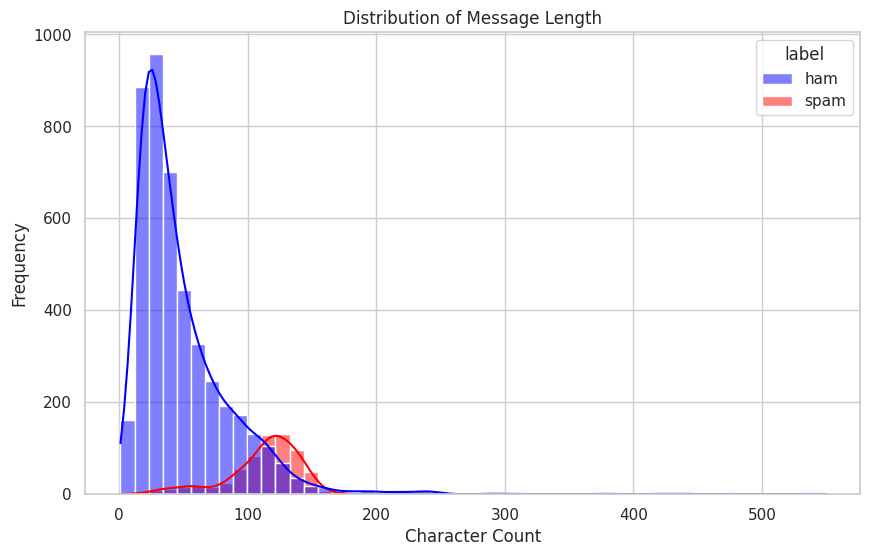

In [153]:
# 设置绘图风格（可选，让图表更好看）
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

# 使用 hue 参数直接区分 ham 和 spam
# common_norm=False 是关键，因为它能让两个类别的密度曲线在各自规模下对比，而不是共享缩放
sns.histplot(data=df, x='length', hue='label', bins=50, kde=True,
             palette={'ham': 'blue', 'spam': 'red'}, common_norm=False)

plt.title('Distribution of Message Length')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
# 使用 hue 之后，Seaborn 会自动生成带标题的图例，不需要手动 plt.legend()
plt.show()

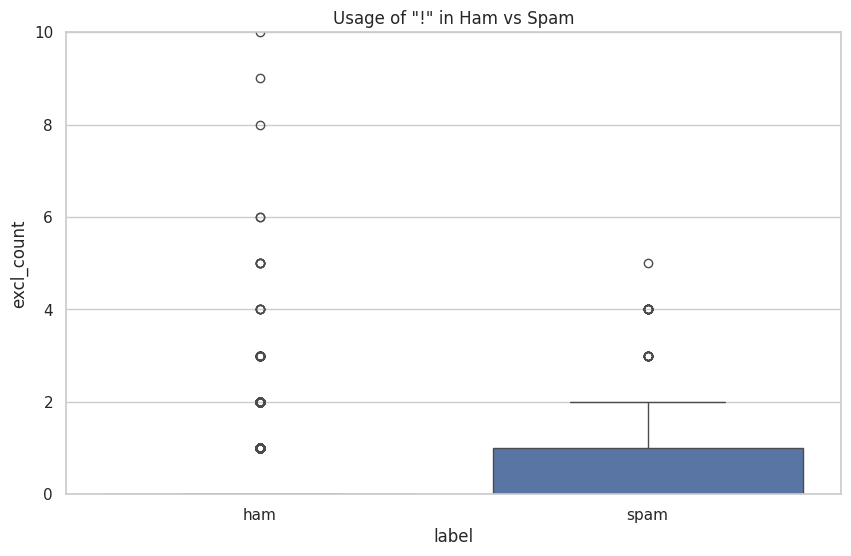

In [154]:
#统计感叹号和美元符号的出现频率
df['excl_count'] = df['text'].apply(lambda x: x.count('!'))
df['dollar_count'] = df['text'].apply(lambda x: x.count('$'))

# 可视化感叹号的使用情况
plt.figure(figsize=(10,6))
sns.boxplot(x='label', y='excl_count', data=df)
plt.title('Usage of "!" in Ham vs Spam')
plt.ylim(0, 10) # 限制 y 轴以便观察主要趋势
plt.show()

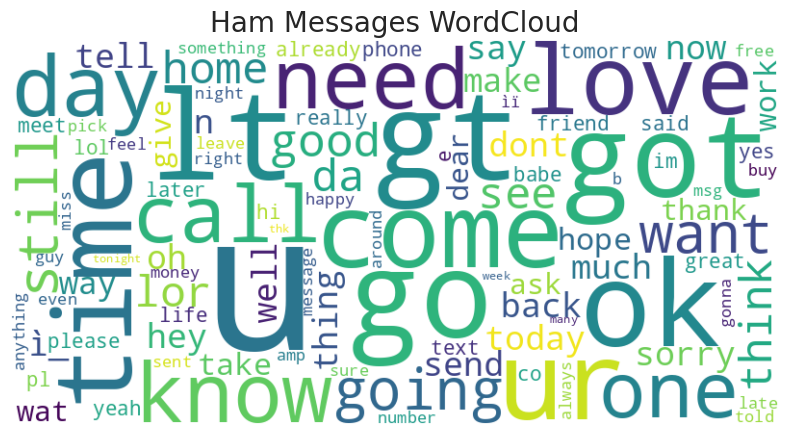

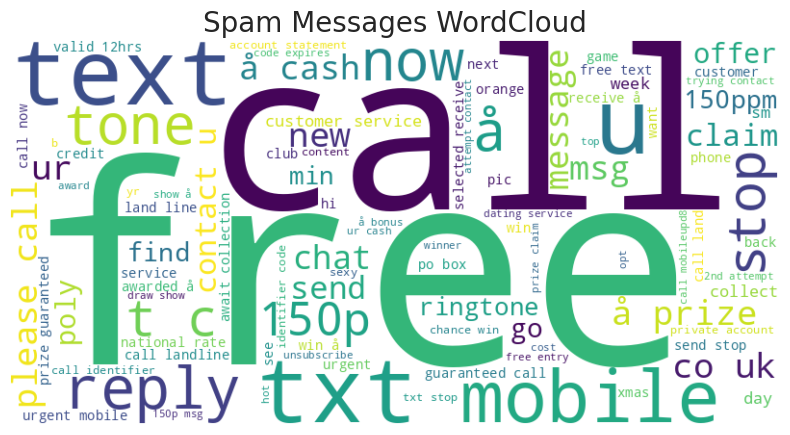

In [155]:
from wordcloud import WordCloud

def show_wordcloud(data, title):
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(' '.join(data))
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')
    plt.show()

# 正常短信词云
show_wordcloud(df[df['label_num']==0]['clean_text'], "Ham Messages WordCloud")

# 垃圾短信词云
show_wordcloud(df[df['label_num']==1]['clean_text'], "Spam Messages WordCloud")

In [156]:
print(df.head())
print(df['label'].value_counts())

  label                                               text  label_num  \
0   ham  Go until jurong point, crazy.. Available only ...          0   
1   ham                      Ok lar... Joking wif u oni...          0   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...          1   
3   ham  U dun say so early hor... U c already then say...          0   
4   ham  Nah I don't think he goes to usf, he lives aro...          0   

                                          clean_text  length  excl_count  \
0  go jurong point, crazy.. available bugis n gre...      91           0   
1                      ok lar... joking wif u oni...      29           0   
2  free entry 2 wkly comp win fa cup final tkts 2...     141           0   
3          u dun say early hor... u c already say...      41           0   
4               nah think go usf, life around though      36           0   

   dollar_count  
0             0  
1             0  
2             0  
3             0  
4             

## **Phase 3 & 4: Model Selection and Evaluation**
We train a Multinomial Naive Bayes model using TF-IDF features and evaluate its performance using a confusion matrix and classification report.


Starting training and evaluation...

Model: Multinomial Naive Bayes
Accuracy: 0.9720
------------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       889
           1       0.87      0.94      0.90       145

    accuracy                           0.97      1034
   macro avg       0.93      0.96      0.94      1034
weighted avg       0.97      0.97      0.97      1034



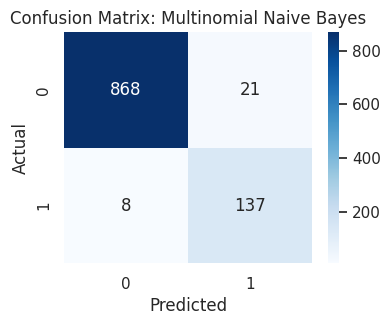


Model: Logistic Regression
Accuracy: 0.9826
------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       889
           1       0.94      0.94      0.94       145

    accuracy                           0.98      1034
   macro avg       0.96      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



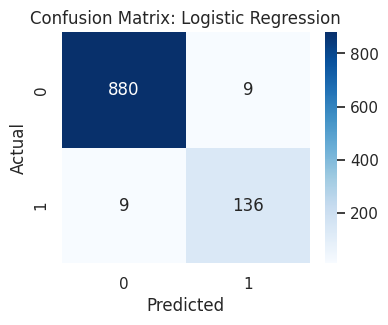


Model: Random Forest
Accuracy: 0.9787
------------------------------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       1.00      0.85      0.92       145

    accuracy                           0.98      1034
   macro avg       0.99      0.92      0.95      1034
weighted avg       0.98      0.98      0.98      1034



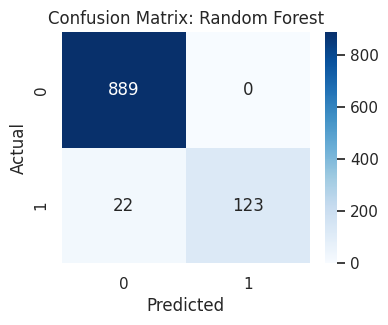

In [157]:
# 初始化三个不同的模型
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

# 存储结果用于最后的对比
results = {}

print("\nStarting training and evaluation...")

for name, model in models.items():
    # 训练模型
    model.fit(X_train_res, y_train_res)

    # 预测
    y_pred = model.predict(X_test)

    # 计算准确率
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # 输出详细报告
    print(f"\n{'='*30}")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print(f"{'-'*30}")
    print(classification_report(y_test, y_pred))

    # 绘制混淆矩阵
    plt.figure(figsize=(4, 3))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

## **Real-time System Demonstration**
This section allows us to input new, unseen messages to test the model's predictive power in a real-world scenario.

--- Final Performance Summary ---
                     Model  Accuracy
1      Logistic Regression  0.982592
2            Random Forest  0.978723
0  Multinomial Naive Bayes  0.971954


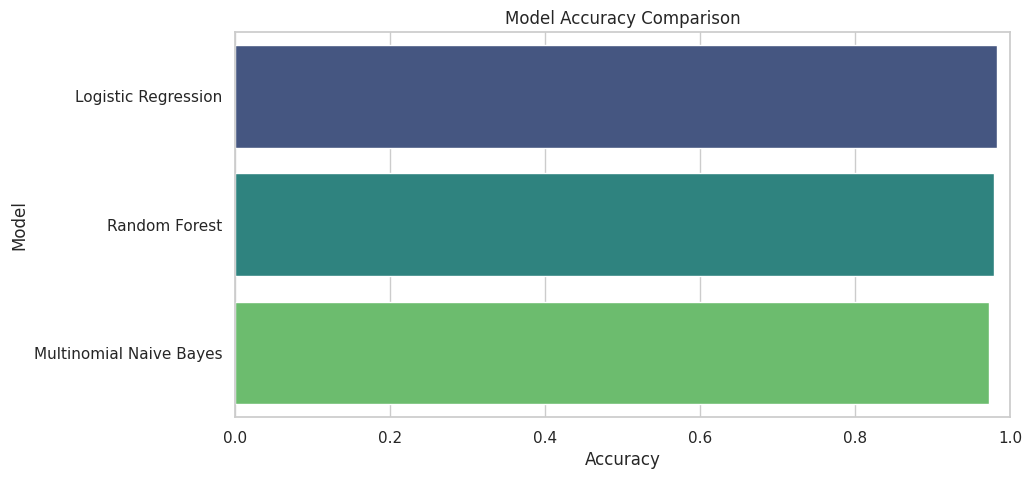

In [158]:
print("--- Final Performance Summary ---")
summary_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
summary_df = summary_df.sort_values(by='Accuracy', ascending=False)
print(summary_df)
# 可视化模型对比
plt.figure(figsize=(10, 5))

# 修正点：显式指定 hue='Model'，并将 legend 设置为 False
sns.barplot(
    x='Accuracy',
    y='Model',
    data=summary_df,
    hue='Model',       # 将颜色映射绑定到 Model 列
    palette='viridis',
    legend=False       # 隐藏多余的图例
)

plt.title('Model Accuracy Comparison')
plt.xlim(0, 1.0)
plt.show()